<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Proyecto del Curso</center></b><h2>
<h3><b><center>La aproximación de Apophis en 2029</center></b><h3>
<h7><center><i>Última actualización del profesor</b>: Viernes 6 de marzo de 2026, 7:00 am</i></center><h7>
</p>

## Enunciado

<center>
<img src="https://starwalk.space/gallery/images/apophis-size/1920x1080.jpg" align="center" width="100%"></center>

En abril de 2029 el asteroide **(99942) Apophis** tendrá [una aproximación extrema con la Tierra](https://arxiv.org/pdf/2201.12205]). Por el tamaño del asteroide, esta aproximación es considerada uno de los eventos astronómicos más importantes de esta década. En este proyecto usaremos la teoría, los métodos y los algorítmos vistos en el curso de Mecánica Celeste para estudiar la aproximación del asteroide.

El objetivo de este trabajo es que experimentes de primera mano lo que las personas expertas en mecánica celeste hacen cuando estudian las amenazas de asteroides. Aprovecha cada cosa que veas en el curso para crear un reporte científico que explore a fondo las características dinámicas de esta aproximación.

## Algunas ideas

Existen muchas maneras de aplicar la teoría que veremos en el curso en este problema y no queremos sesgar tu elección de los temas o cálculos que quieras escoger para aplicarla. Sin embargo aquí van algunas ideas de cálculos que se podrían hacer:
- Integración de la trayectoria del asteroide usando un integrador de N cuerpos y teniendo en cuenta los efectos de todos los planetas.
- Cálculo de la fecha y hora exacta de aproximación a la Tierra.
- Determinación de la distancia mínima de la órbita del asteroide a la órbita de la Tierra.
- Cálculo usando solo la teoría del problema de los dos cuerpos de la aproximación y comparación con la teoría de N cuerpos.
- Cálculo del cambio de la órbita heliocéntrica del asteroide después de su paso cerca de la Tierra.
- Aplicación de la teoría del problema de N cuerpos al asteroide.

En todos los casos debe ser evidente cómo estás usando los resultados teóricos que vemos en el curso.

## Entregables

El entregable del proyecto es **un notebook final de Jupyter** con una descripción de la teoría básica que uses, los experimentos numéricos que hayas realizado y las conclusiones a las que llegues con esos experimentos. Por supuesto puedes desarrollar otros programas y notebooks paralelos, pero se revisará el notebook con el reporte final.

Adicionalmente se deberá entregar **un repositorio de GitHub** que tenga todos los archivos, datos, notebooks, programas usados para este propósito. El notebook debe estar alojado en el repositorio.

## Criterios de evaluación

Una vez entregues el proyecto el profesor realizará una revisión del mismo y te lo devolverá con observaciones. En la segunda revisión emitirá un concepto cuantitativo del proyecto. Los criterios a evaluar serán:

- Correcta descripción y aplicación de la teoría.
- Originalidad de los experimentos numéricos.
- Conclusiones derivadas de los experimentos.
- Organización y extensión del reporte final.
- Ritmo de actualizaciones del repositorio de GitHub.

## Para tener en cuenta

- La solución presentada debe ser estrictamente individual. Evite resolver la tarea en parejas o en grupos que puede conducir a códigos o soluciones idénticos o muy similares.
- Los métodos y herramientas para resolver el problema deben ser los vistos en clase. El uso de herramientas diferentes puede ser una buena práctica en el mundo académico o laboral, pero en un curso puede también ser un indicio de un mal uso de las *asesorías* externa o del uso inapropiado de herramientas de Inteligencia Artificial (IA).
- El notebook entregado debe tener todos los resultados y gráficos, calculados y a la vista.  También debe ejecutarse completamente con `Ejecutar Todo` sin producir ningún error (verifique antes de entregar).
- El notebook debe tener explicaciones detalladas para cada paso del procedimiento usando celdas de texto. No debe poner una celda de código sin explicarla. En caso de incluir ecuaciones debe usar $\LaTeX$.

---
## 1. Marco Teórico

### 1.1 El Baricentro del Sistema Solar (SSB)

El **Baricentro del Sistema Solar** (Solar System Barycenter, SSB) es el centro de masa de todo el Sistema Solar. Si denotamos la masa del cuerpo $i$ como $m_i$ y su posición como $\vec{r}_i$, el SSB se define como:

$$\vec{R}_{\rm SSB} = \frac{\sum_i m_i \, \vec{r}_i}{\sum_i m_i}$$

Por definición, en el **marco del SSB** el **momento lineal total** del Sistema Solar es cero:

$$\vec{P}_{\rm total} = \sum_i m_i \, \vec{v}_i = \vec{0}$$

Esto lo convierte en un **sistema de referencia inercial** (o casi inercial para propósitos prácticos), lo que significa que las leyes de Newton se aplican directamente sin términos de arrastre ficticios.

| Marco de referencia | Origen | Inercial | Usado por |
|---|---|---|---|
| **SSB eclíptico J2000** | Baricentro del SS | Sí | JPL DE441, SPICE |
| Heliocéntrico eclíptico J2000 | Centro del Sol | $\approx$ Sí (el Sol oscila ~0.01 AU) | Astronomía clásica |
| Geocéntrico | Centro de la Tierra | No (acelerado) | Satélites, observaciones |


### 1.2 El eje eclíptico J2000

Las posiciones y velocidades en el SSB se expresan en el sistema de coordenadas **eclíptico J2000**:
- **Eje X**: apunta hacia el equinoccio vernal del año 2000.0.
- **Eje Z**: perpendicular al plano de la eclíptica (plano de la órbita terrestre).
- **Eje Y**: completa la base derecha $\vec{z} = \vec{x} \times \vec{y}$.

Este es el sistema que usa JPL Horizons por defecto al pedir vectores de estado (`COORD_TYPE=2`).

---

### 1.3 Vectores de Estado: Posición y Velocidad

El **vector de estado** de un cuerpo en el SSB tiene 6 componentes:

$$\vec{y}_i = (x_i, y_i, z_i, \dot{x}_i, \dot{y}_i, \dot{z}_i) = (\vec{r}_i, \vec{v}_i)$$

donde:
- $(x_i, y_i, z_i)$ es la posición en Unidades Astronómicas (UA).
- $(\dot{x}_i, \dot{y}_i, \dot{z}_i)$ es la velocidad en UA/día.

JPL Horizons proporciona estos datos para cualquier cuerpo del Sistema Solar a partir de las **efemérides DE441** (integración numérica de alta precisión).

---

### 1.4 El Parámetro Gravitacional $\mu = GM$

La constante gravitacional universal $G = 6.674 \times 10^{-11}$ m³ kg⁻¹ s⁻² se conoce con una precisión relativa de ~22 ppm, mientras que el **parámetro gravitacional** $\mu_i = GM_i$ se conoce con muchísima mayor precisión (hasta 11 dígitos significativos) mediante observaciones orbitales de naves espaciales.

Por esta razón, en astrodinámica se trabaja directamente con $\mu$ en lugar de $G$ y $M$ por separado:

| Cuerpo | $\mu = GM$ (m³/s²) | $\mu$ (UA³/día²) | $m/M_\odot$ |
|--------|---------------------|------------------|---------------|
| **Sol** | $1.32712 \times 10^{20}$ | $2.9592 \times 10^{-4}$ | $1.0$ |
| **Tierra** | $3.9860 \times 10^{14}$ | $8.8878 \times 10^{-10}$ | $3.003 \times 10^{-6}$ |
| **Luna** | $4.9048 \times 10^{12}$ | $1.0931 \times 10^{-11}$ | $3.694 \times 10^{-8}$ |
| **Apophis** | $\approx 1.8 \times 10^{0}$ | $\approx 4 \times 10^{-24}$ | $\approx 1.4 \times 10^{-20}$ |

---

### 1.5 El Problema de N-Cuerpos: Ecuaciones de Movimiento

Para un sistema de $N$ cuerpos con masas $m_i$ y posiciones $\vec{r}_i$ respecto al SSB, las ecuaciones de movimiento de Newton son:

$$\boxed{\ddot{\vec{r}}_i = \sum_{j \neq i} \frac{G m_j (\vec{r}_j - \vec{r}_i)}{|\vec{r}_j - \vec{r}_i|^3}}$$

En nuestra simulación tenemos $N = 4$ cuerpos: Sol, Tierra, Luna y Apophis. Esto nos da un sistema de $4 \times 3 = 12$ EDOs de segundo orden, o equivalentemente $24$ EDOs de primer orden.

**Constantes de movimiento:**
- Energía mecánica total: $E = \frac{1}{2}\sum_i m_i v_i^2 - \sum_{i<j} \frac{G m_i m_j}{|\vec{r}_i - \vec{r}_j|}$
- Momento lineal total: $\vec{P} = \sum_i m_i \vec{v}_i = \vec{0}$ (en el SSB)
- Momento angular total: $\vec{L} = \sum_i m_i (\vec{r}_i \times \vec{v}_i)$

# Instalación de las librerías necesarias

In [3]:
!pip install celluloid astropy pymcel -q

# Importar librerías y tomar el warning para evitar ruido en los resultados

In [4]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Definir las constantes físicas y los factores de conversión de unidades necesarios para pasar del Sistema Internacional (metros, segundos) a unidades astronómicas (UA, días).

In [5]:
# Constantes de conversión
AU_m   = pc.constantes.au      # 1 UA en metros
day_s  = pc.constantes.día     # 1 día en segundos
yr_d   = pc.constantes.yr / pc.constantes.día  # 1 año en días
G_SI   = pc.constantes.G       # Constante gravitacional [m^3 kg^-1 s^-2]
c_luz  = pc.constantes.c       # Velocidad de la luz [m/s]

# Factor de conversión de mu: m^3/s^2 -> UA^3/día^2
fac_mu = day_s**2 / AU_m**3

# Parámetros gravitacionales $\mu$ de los principales cuerpos del Sistema Solar (incluyendo a Apophis), calcula sus valores equivalentes en unidades astronómicas y sus masas relativas al Sol, y organiza toda esta información en un DataFrame de pandas para su visualización y uso posterior en la simulación.

In [6]:
# Constantes gravitacionales (SI) m^3/s^2
mu_sun_SI      = pc.constantes.mu_sun
mu_mercury_SI  = pc.constantes.mu_mercury
mu_venus_SI    = pc.constantes.mu_venus
mu_earth_SI    = pc.constantes.mu_earth
mu_moon_SI     = pc.constantes.mu_moon
mu_mars_SI     = pc.constantes.mu_mars
mu_jupiter_SI  = pc.constantes.mu_jupiter
mu_saturn_SI   = pc.constantes.mu_saturn
mu_uranus_SI   = pc.constantes.mu_uranus
mu_neptune_SI  = pc.constantes.mu_neptune

m_apophis      = 2.7e10                          # kg
mu_apophis_SI  = G_SI * m_apophis                # m^3/s^2

# Construcción del DataFrame
datos_mu = [
    ('Sol',       mu_sun_SI,     mu_sun_SI * fac_mu,     1.0),
    ('Mercurio',  mu_mercury_SI, mu_mercury_SI * fac_mu, mu_mercury_SI / mu_sun_SI),
    ('Venus',     mu_venus_SI,   mu_venus_SI * fac_mu,   mu_venus_SI / mu_sun_SI),
    ('Tierra',    mu_earth_SI,   mu_earth_SI * fac_mu,   mu_earth_SI / mu_sun_SI),
    ('Luna',      mu_moon_SI,    mu_moon_SI * fac_mu,    mu_moon_SI / mu_sun_SI),
    ('Marte',     mu_mars_SI,    mu_mars_SI * fac_mu,    mu_mars_SI / mu_sun_SI),
    ('Jupiter',   mu_jupiter_SI, mu_jupiter_SI * fac_mu, mu_jupiter_SI / mu_sun_SI),
    ('Saturno',   mu_saturn_SI,  mu_saturn_SI * fac_mu,  mu_saturn_SI / mu_sun_SI),
    ('Urano',     mu_uranus_SI,  mu_uranus_SI * fac_mu,  mu_uranus_SI / mu_sun_SI),
    ('Neptuno',   mu_neptune_SI, mu_neptune_SI * fac_mu, mu_neptune_SI / mu_sun_SI),
    ('Apophis',   mu_apophis_SI, mu_apophis_SI * fac_mu, mu_apophis_SI / mu_sun_SI),
]

cuerpos_mu = pd.DataFrame(datos_mu, columns=['Cuerpo', 'mu (m^3/s^2)', 'mu (UA^3/d^2)', 'm/M_sol'])
cuerpos_mu

,Cuerpo,mu (m^3/s^2),mu (UA^3/d^2),m/M_sol
0,Sol,1.327124e+20,2.959122e-04,1.000000e+00
1,Mercurio,2.203187e+13,4.912500e-11,1.660121e-07
2,Venus,3.248586e+14,7.243452e-10,2.447838e-06
3,Tierra,3.986004e+14,8.887692e-10,3.003490e-06
4,Luna,4.902800e+12,1.093189e-11,3.694303e-08
5,Marte,4.282838e+13,9.549549e-11,3.227156e-07
6,Jupiter,1.267128e+17,2.825346e-07,9.547919e-04
7,Saturno,3.794058e+16,8.459706e-08,2.858857e-04
8,Urano,5.794556e+15,1.292027e-08,4.366250e-05
9,Neptuno,6.836527e+15,1.524357e-08,5.151384e-05


In [7]:
#epochs_ini = {'start': '2026-04-11', 'stop': '2026-04-12', 'step': '1d'}
epochs_ini = "2029-01-01"

# Define funciones para obtener vectores de estado desde JPL Horizons y convertirlos, junto con las masas, a unidades canónicas.

In [8]:
def Estados(cuerpos, propiedades, epochs):
    VectorEstadoSI = {}
    for nombre, id in cuerpos:
        _, _, salida = pc.consulta_horizons(
            id=id,
            location="@0",
            datos="vectors",
            propiedades=propiedades,
            epochs=epochs,
        )
        # Convertir la salida a un vector único [x, y, z, vx, vy, vz]
        VectorEstadoSI[nombre] = np.array(salida, dtype=float).reshape(-1)
    return VectorEstadoSI

def UnidadesCanonicas(EstadosSI, MasasSI, UL=1.495978707e11, UM=1.98847e30):
    UL, UM, UT, Gc = pc.unidades_canonicas(UL=UL, UM=UM)
    vel_unit = UL / UT

    EstadoCanonico = {}
    for nombre, vec in EstadosSI.items():
        # Asegurarse de que el vector tenga 6 elementos: [x, y, z, vx, vy, vz]
        if len(vec) != 6:
            raise ValueError(f"El vector de estado para {nombre} debe tener 6 elementos: [x, y, z, vx, vy, vz]")
        x, y, z, vx, vy, vz = vec
        EstadoCanonico[nombre] = np.array([
            x / UL,
            y / UL,
            z / UL,
            vx / vel_unit,
            vy / vel_unit,
            vz / vel_unit,
        ])

    MasasCanonico = {nombre: MasasSI[nombre] / UM for nombre in MasasSI}
    return EstadoCanonico, MasasCanonico, UL, UM, UT, Gc

# Define la lista de cuerpos celestes y consulta JPL Horizons para obtener y almacenar sus vectores de estado iniciales en una fecha específica.

In [9]:
CUERPOS = [
    ('Sol',       '10',    'majorbody', mu_sun_SI),
    ('Mercurio',  '199',   'majorbody', mu_mercury_SI),
    ('Venus',     '299',   'majorbody', mu_venus_SI),
    ('Tierra',    '399',   'majorbody', mu_earth_SI),
    ('Luna',      '301',   'majorbody', mu_moon_SI),
    ('Marte',     '499',   'majorbody', mu_mars_SI),
    ('Jupiter',   '599',   'majorbody', mu_jupiter_SI),
    ('Saturno',   '699',   'majorbody', mu_saturn_SI),
    ('Urano',     '799',   'majorbody', mu_uranus_SI),
    ('Neptuno',   '899',   'majorbody', mu_neptune_SI),
    ('Apophis',   '99942', 'smallbody', mu_apophis_SI),
]

epochs_ini = '2029-01-01'  # Solo una fecha

estados_ini = {}

for nombre, horizons_id, id_type, mu in CUERPOS:
    print(f'Consultando Horizons para {nombre} (ID={horizons_id})...')
    try:
        # pc.consulta_horizons devuelve una tupla: (tabla, tiempo_jd, vector_estado)
        tabla, tiempo_jd, vector_estado = pc.consulta_horizons(
            id=horizons_id,
            location='@0',
            epochs=epochs_ini,
            datos='vectors',
        )
        # El vector de estado ya está en el formato [x, y, z, vx, vy, vz]
        estados_ini[nombre] = vector_estado
    except Exception as e:
        print(f"Error al consultar {nombre}: {e}")

# Verificar el resultado
for nombre, vector in estados_ini.items():
    print(f"{nombre}: {vector}")

Consultando Horizons para Sol (ID=10)...
Consultando Horizons para Mercurio (ID=199)...
Consultando Horizons para Venus (ID=299)...
Consultando Horizons para Tierra (ID=399)...
Consultando Horizons para Luna (ID=301)...
Consultando Horizons para Marte (ID=499)...
Consultando Horizons para Jupiter (ID=599)...
Consultando Horizons para Saturno (ID=699)...
Consultando Horizons para Urano (ID=799)...
Consultando Horizons para Neptuno (ID=899)...
Consultando Horizons para Apophis (ID=99942)...
Sol: [ 1.84485534e+08 -2.06688685e+08  4.68177882e+06 -7.07905228e-01
  9.08755465e+00 -1.59729726e-02]
Mercurio: [ 4.57696300e+10  1.90969458e+10 -2.59830871e+09 -2.84706363e+04
  4.70237667e+04  6.45337759e+03]
Venus: [-6.44802810e+10 -8.71084482e+10  2.54112934e+09  2.78505275e+04
 -2.10609194e+04 -1.89666010e+03]
Tierra: [-2.64894151e+10  1.44454539e+11 -4.75199991e+06 -2.97678141e+04
 -5.49983655e+03  1.68906951e+00]
Luna: [-2.65819383e+10  1.44819466e+11 -5.17747475e+06 -3.07691630e+04
 -5.79759

In [10]:
print(f'Época inicial de la simulación: {epochs_ini}')
print(f'Cuerpos incluidos en la simulación: {[c[0] for c in CUERPOS]}')

Época inicial de la simulación: 2029-01-01
Cuerpos incluidos en la simulación: ['Sol', 'Mercurio', 'Venus', 'Tierra', 'Luna', 'Marte', 'Jupiter', 'Saturno', 'Urano', 'Neptuno', 'Apophis']


In [11]:
estados_ini

{'Sol': array([ 1.84485534e+08, -2.06688685e+08,  4.68177882e+06, -7.07905228e-01,
         9.08755465e+00, -1.59729726e-02]),
 'Mercurio': array([ 4.57696300e+10,  1.90969458e+10, -2.59830871e+09, -2.84706363e+04,
         4.70237667e+04,  6.45337759e+03]),
 'Venus': array([-6.44802810e+10, -8.71084482e+10,  2.54112934e+09,  2.78505275e+04,
        -2.10609194e+04, -1.89666010e+03]),
 'Tierra': array([-2.64894151e+10,  1.44454539e+11, -4.75199991e+06, -2.97678141e+04,
        -5.49983655e+03,  1.68906951e+00]),
 'Luna': array([-2.65819383e+10,  1.44819466e+11, -5.17747475e+06, -3.07691630e+04,
        -5.79759026e+03, -9.47705451e+01]),
 'Marte': array([-2.10696773e+11,  1.31915252e+11,  7.94414962e+09, -1.19557872e+04,
        -1.84541894e+04, -9.39140078e+01]),
 'Jupiter': array([-7.89580901e+11, -2.04160295e+11,  1.85226430e+10,  3.11566176e+03,
        -1.20434471e+04, -1.96230337e+01]),
 'Saturno': array([ 1.05942345e+12,  8.77603409e+11, -5.74447089e+10, -6.68527771e+03,
       

# Construcción del sistema en pymcel

In [12]:
#  Construcción del sistema para pymcel

sistema = []
nombres_sim = []  # para etiquetas

for nombre, horizons_id, id_type, mu_si in CUERPOS:
    data = estados_ini[nombre]

    # Obtener mu en UA^3/d^2 del DataFrame cuerpos_mu
    mu_ua_day = cuerpos_mu.loc[cuerpos_mu['Cuerpo'] == nombre, 'mu (UA^3/d^2)'].iloc[0]

    r_au = np.array(data[:3]) / AU_m
    v_au_day = np.array(data[3:]) * day_s / AU_m

    sistema.append(dict(
        m = mu_ua_day,   # En UA^3/d^2 (G=1 canónico)
        r = r_au.tolist(), # AU
        v = v_au_day.tolist(), # AU/day
    ))
    nombres_sim.append(nombre)

# Imprimir configuración
print('Sistema de simulación:')
print(f'{"Cuerpo":<10} {"μ (UA^3/d^2)":>16} {"r [UA]":<40} {"v [UA/d]"}')
print('-'*100)
for i, (cuerpo, s) in enumerate(zip(nombres_sim, sistema)):
    rv = np.array(s['r'])
    vv = np.array(s['v'])
    print(f'{cuerpo:<10} {s["m"]:>16.4e}  [{rv[0]:+.4f}, {rv[1]:+.4f}, {rv[2]:+.5f}]  '
          f'[{vv[0]:+.6f}, {vv[1]:+.6f}, {vv[2]:+.6f}]')


Sistema de simulación:
Cuerpo         μ (UA^3/d^2) r [UA]                                   v [UA/d]
----------------------------------------------------------------------------------------------------
Sol              2.9591e-04  [+0.0012, -0.0014, +0.00003]  [-0.000000, +0.000005, -0.000000]
Mercurio         4.9125e-11  [+0.3060, +0.1277, -0.01737]  [-0.016443, +0.027158, +0.003727]
Venus            7.2435e-10  [-0.4310, -0.5823, +0.01699]  [+0.016085, -0.012164, -0.001095]
Tierra           8.8877e-10  [-0.1771, +0.9656, -0.00003]  [-0.017192, -0.003176, +0.000001]
Luna             1.0932e-11  [-0.1777, +0.9681, -0.00003]  [-0.017771, -0.003348, -0.000055]
Marte            9.5495e-11  [-1.4084, +0.8818, +0.05310]  [-0.006905, -0.010658, -0.000054]
Jupiter          2.8253e-07  [-5.2780, -1.3647, +0.12382]  [+0.001799, -0.006956, -0.000011]
Saturno          8.4597e-08  [+7.0818, +5.8664, -0.38399]  [-0.003861, +0.004286, +0.000079]
Urano            1.2920e-08  [+5.9212, +18.3564, -0.00

# Define el vector de tiempo y ejecuta la integración numérica de N-cuerpos para obtener las trayectorias del sistema.

In [13]:
# Vector de tiempos
N_PASOS = 1000
T_FINAL = 2*365.0    # días
ts = np.linspace(0.0, T_FINAL, N_PASOS)

# Integración de N-Cuerpos con pymcel
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)

# Grafica las trayectorias orbitales en el plano XY de los cuerpos seleccionados.

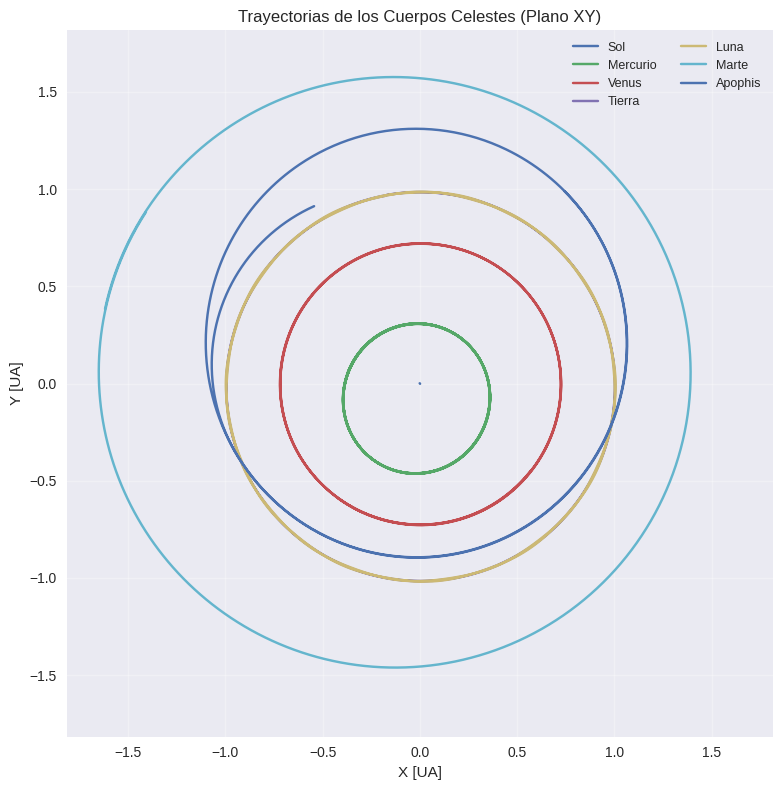

In [14]:
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(10, 8))


max_coord = 0


bodies_to_plot = nombres_sim[:nombres_sim.index('Marte') + 1]
if 'Apophis' in nombres_sim:
    bodies_to_plot.append('Apophis')

for nombre in bodies_to_plot:
    i = nombres_sim.index(nombre)
    r_plot_x = rs[i, :, 0]
    r_plot_y = rs[i, :, 1]
    plt.plot(r_plot_x, r_plot_y, label=nombre)

    max_x = np.max(np.abs(r_plot_x))
    max_y = np.max(np.abs(r_plot_y))
    max_coord = max(max_coord, max_x, max_y)

plot_limit = max_coord * 1.1
plt.xlim(-plot_limit, plot_limit)
plt.ylim(-plot_limit, plot_limit)

plt.xlabel('X [UA]')
plt.ylabel('Y [UA]')
plt.title('Trayectorias de los Cuerpos Celestes (Plano XY)')
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# Grafica las proyecciones de las trayectorias en los planos XY, XZ y YZ.

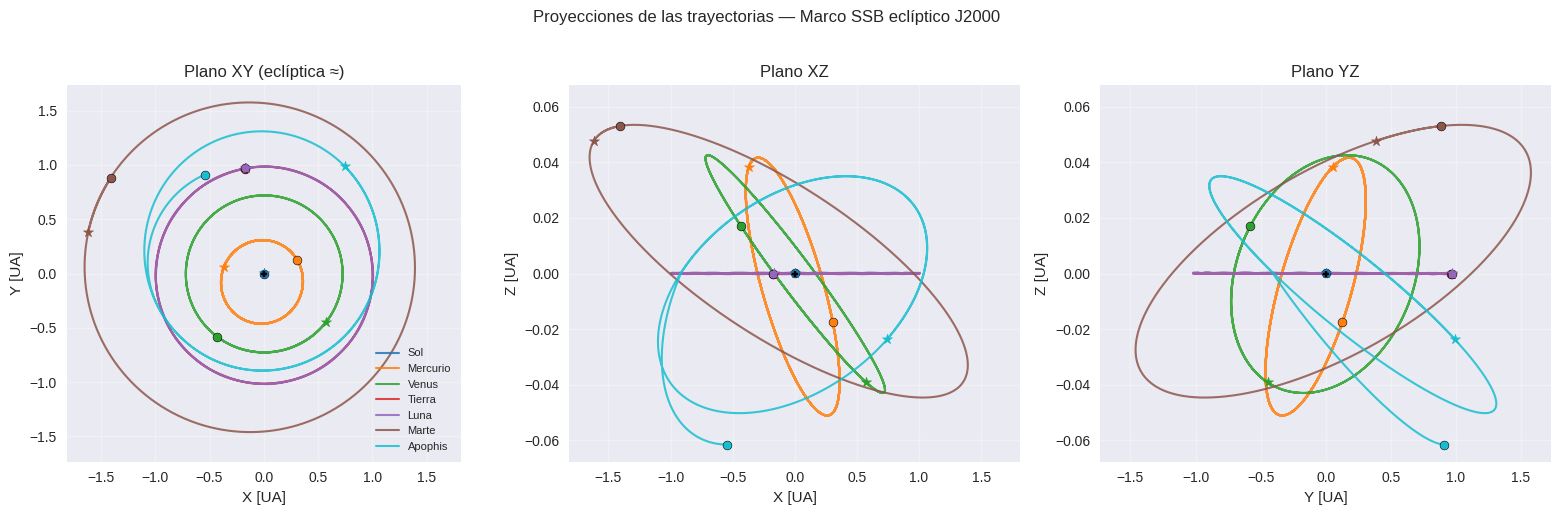

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

planos = [
    (0, 1, 'X [UA]', 'Y [UA]', 'Plano XY (eclíptica ≈)'),
    (0, 2, 'X [UA]', 'Z [UA]', 'Plano XZ'),
    (1, 2, 'Y [UA]', 'Z [UA]', 'Plano YZ'),
]

colores = {nombre: plt.cm.tab10(i) for i, nombre in enumerate(nombres_sim)}


bodies_to_plot = nombres_sim[:nombres_sim.index('Marte') + 1]
if 'Apophis' in nombres_sim:
    bodies_to_plot.append('Apophis')

for ax, (ix, iy, xl, yl, titulo) in zip(axes, planos):
    max_val_x_current_plane = 0
    max_val_y_current_plane = 0

    for nombre in bodies_to_plot:
        i = nombres_sim.index(nombre)
        tray = rs[i]
        c = colores[nombre]
        ax.plot(tray[:, ix], tray[:, iy], '-', color=c, linewidth=1.5,
                label=nombre, alpha=0.85)

        ax.scatter(tray[0, ix], tray[0, iy], s=40, color=c,
                   edgecolors='k', linewidths=0.4, zorder=5)

        ax.scatter(tray[-1, ix], tray[-1, iy], s=60, color=c, marker='*', zorder=5)


        max_val_x_current_plane = max(max_val_x_current_plane, np.max(np.abs(tray[:, ix])))
        max_val_y_current_plane = max(max_val_y_current_plane, np.max(np.abs(tray[:, iy])))

    plot_limit_x = max_val_x_current_plane * 1.1
    plot_limit_y = max_val_y_current_plane * 1.1

    ax.set_xlim(-plot_limit_x, plot_limit_x)
    ax.set_ylim(-plot_limit_y, plot_limit_y)


    ax.scatter(0, 0, s=25, color='k', marker='+', zorder=6)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(titulo)


    if titulo == 'Plano XY (eclíptica ≈)':
        ax.set_aspect('equal', adjustable='box')

    else:
        ax.set_aspect('auto', adjustable='box')

    if ax == axes[0]:
        ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Proyecciones de las trayectorias — Marco SSB eclíptico J2000', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Funciones para calcular energías

Calcula las energías cinética, potencial y total del sistema para verificar su conservación.

In [16]:
def calcular_energia_cinetica(vs_step, sistema):
    energia_cinetica = 0.0
    for i, body_data in enumerate(sistema):
        m_i = body_data['m']
        v_i = vs_step[i] # Velocidad del cuerpo i en este paso de tiempo
        energia_cinetica += 0.5 * m_i * np.linalg.norm(v_i)**2
    return energia_cinetica

def calcular_energia_potencial(rs_step, sistema, Gc=1.0):
    energia_potencial = 0.0
    num_cuerpos = len(sistema)
    for i in range(num_cuerpos):
        for j in range(i + 1, num_cuerpos):
            m_i = sistema[i]['m']
            m_j = sistema[j]['m']
            r_i = rs_step[i]
            r_j = rs_step[j]

            # Distancia entre los cuerpos i y j
            distancia = np.linalg.norm(r_i - r_j)

            if distancia > 0: # Evitar división por cero si los cuerpos están en la misma posición
                energia_potencial -= (Gc * m_i * m_j) / distancia
    return energia_potencial



energias_cineticas = []
energias_potenciales = []

Gc_canonical = 1.0

for t in range(N_PASOS):

    rs_t = rs[:, t, :]
    vs_t = vs[:, t, :]

    K_t = calcular_energia_cinetica(vs_t, sistema)
    energias_cineticas.append(K_t)

    U_t = calcular_energia_potencial(rs_t, sistema, Gc=Gc_canonical)
    energias_potenciales.append(U_t)

energias_cineticas = np.array(energias_cineticas)
energias_potenciales = np.array(energias_potenciales)
energias_totales = energias_cineticas + energias_potenciales

print("Energías calculadas para cada paso de tiempo.")
print(f"Energía Cinética (inicial): {energias_cineticas[0]:.4e}")
print(f"Energía Potencial (inicial): {energias_potenciales[0]:.4e}")
print(f"Energía Total (inicial): {energias_totales[0]:.4e}")

energia_total_promedio = np.mean(energias_totales)
variacion_maxima_energia = np.max(np.abs(energias_totales - energia_total_promedio)) / np.abs(energia_total_promedio)
print(f"Variación máxima relativa de la energía total: {variacion_maxima_energia:.2e}")

Energías calculadas para cada paso de tiempo.
Energía Cinética (inicial): 9.1971e-12
Energía Potencial (inicial): -1.9028e-11
Energía Total (inicial): -9.8314e-12
Variación máxima relativa de la energía total: 1.50e-08


La energía total negativa confirma que el sistema está gravitacionalmente ligado. La ínfima variación de energía ($\sim 10^{-8}$) demuestra una excelente estabilidad y conservación en la integración numérica.

# Gráfico de energía cinetica, potencial y total a lo largo del tiempo


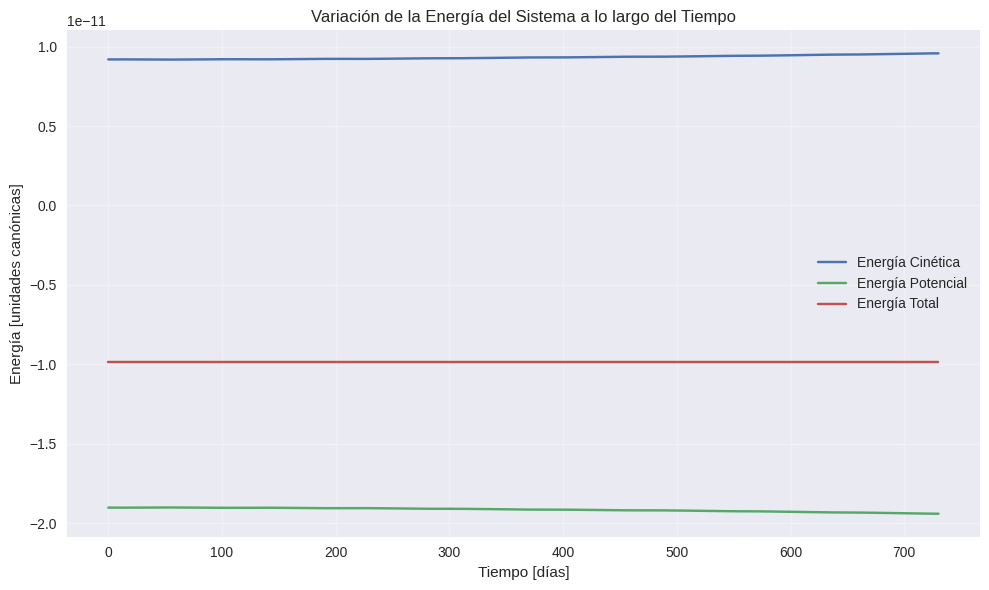

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(ts, energias_cineticas, label='Energía Cinética')
plt.plot(ts, energias_potenciales, label='Energía Potencial')
plt.plot(ts, energias_totales, label='Energía Total')

plt.xlabel('Tiempo [días]')
plt.ylabel('Energía [unidades canónicas]')
plt.title('Variación de la Energía del Sistema a lo largo del Tiempo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico del plano XY y XZ con todos los cuerpos

Debido a las grandes distancias, este tipo de gráficos no logra transmitirnos una impresión visual adecuada, es por eso, que mejor se muestran gráficos con los cuerpos desde el sol hasta marte. Para poder tener una mejor impresión. De todas maneras, se están teniendo encuenta las interacciones gravitacionales de todos los cuerpos

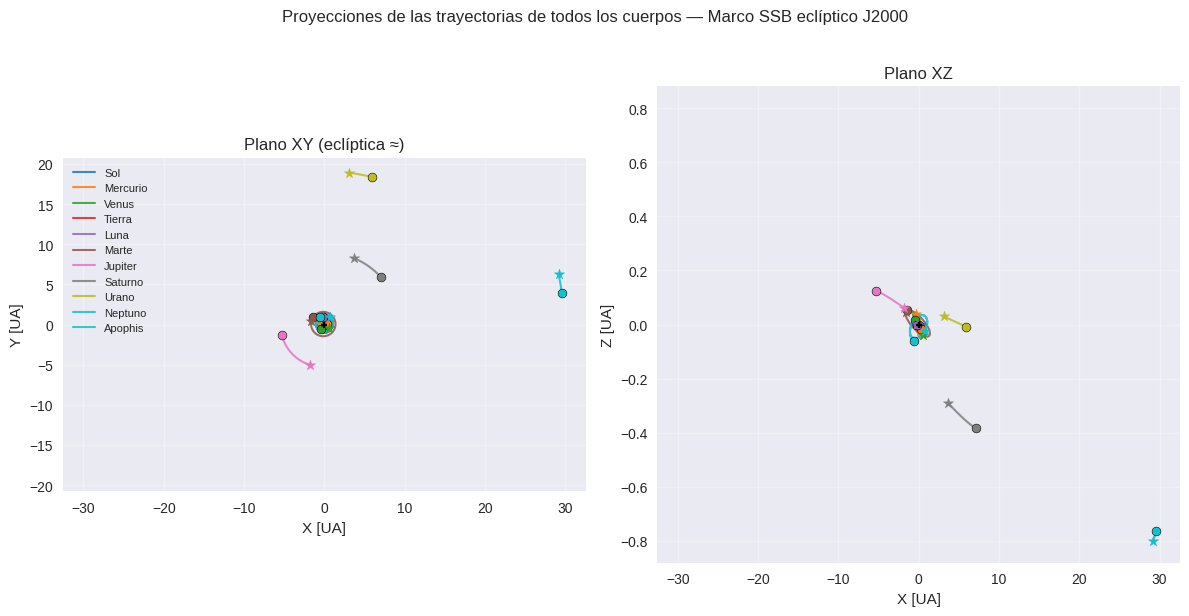

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

planos_2d = [
    (0, 1, 'X [UA]', 'Y [UA]', 'Plano XY (eclíptica ≈)')
    , (0, 2, 'X [UA]', 'Z [UA]', 'Plano XZ')
]

colores = {nombre: plt.cm.tab10(i) for i, nombre in enumerate(nombres_sim)}

# Use nombres_sim for all bodies as requested
# No need to filter bodies here, as the request is 'todos los cuerpos'
bodies_to_plot_all = nombres_sim

for ax, (ix, iy, xl, yl, titulo) in zip(axes, planos_2d):
    max_val_x_current_plane = 0
    max_val_y_current_plane = 0

    for nombre in bodies_to_plot_all:
        i = nombres_sim.index(nombre)
        tray = rs[i] # Using rs from the pymcel simulation
        c = colores[nombre]
        ax.plot(tray[:, ix], tray[:, iy], '-', color=c, linewidth=1.5,
                label=nombre, alpha=0.85)

        ax.scatter(tray[0, ix], tray[0, iy], s=40, color=c,
                   edgecolors='k', linewidths=0.4, zorder=5)

        ax.scatter(tray[-1, ix], tray[-1, iy], s=60, color=c, marker='*', zorder=5)


        max_val_x_current_plane = max(max_val_x_current_plane, np.max(np.abs(tray[:, ix])))
        max_val_y_current_plane = max(max_val_y_current_plane, np.max(np.abs(tray[:, iy])))

    plot_limit_x = max_val_x_current_plane * 1.1
    plot_limit_y = max_val_y_current_plane * 1.1

    ax.set_xlim(-plot_limit_x, plot_limit_x)
    ax.set_ylim(-plot_limit_y, plot_limit_y)


    ax.scatter(0, 0, s=25, color='k', marker='+', zorder=6)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(titulo)


    if titulo == 'Plano XY (eclíptica ≈)':
        ax.set_aspect('equal', adjustable='box')
    else:
        ax.set_aspect('auto', adjustable='box')

    if ax == axes[0]: # Only add legend to the first subplot to avoid redundancy
        ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Proyecciones de las trayectorias de todos los cuerpos — Marco SSB eclíptico J2000', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Virial Escalar $G$

$$G(t) = \sum_{i} m_i (\vec{r}_i \cdot \vec{v}_i)$$

# Tasa de Cambio del Virial $\dot{G}$:

$$\dot{G}(t) = \frac{dG}{dt} = 2K + U$$

Define funciones para calcular el virial escalar y su derivada para verificar el Teorema del Virial.

In [19]:
def calcular_virial_escalar(rs_step, vs_step, sistema):
    virial_escalar = 0.0
    for i, body_data in enumerate(sistema):
        m_i = body_data['m']
        r_i = rs_step[i]
        v_i = vs_step[i]
        virial_escalar += m_i * np.dot(r_i, v_i)
    return virial_escalar

def calcular_derivada_virial(K, U):
    return 2 * K + U

Calcula y almacena el virial escalar y su derivada temporal para cada paso de la simulación.

In [20]:
# Calcular el virial escalar y su derivada para cada paso de tiempo
viriales_escalares = []
derivadas_viriales = []

for t in range(N_PASOS):
    rs_t = rs[:, t, :]
    vs_t = vs[:, t, :]

    # Calcular el virial escalar
    G_t = calcular_virial_escalar(rs_t, vs_t, sistema)
    viriales_escalares.append(G_t)

    # K_t y U_t ya están calculadas en energias_cineticas y energias_potenciales
    K_t = energias_cineticas[t]
    U_t = energias_potenciales[t]

    # Calcular la derivada del virial
    dG_dt = calcular_derivada_virial(K_t, U_t)
    derivadas_viriales.append(dG_dt)

viriales_escalares = np.array(viriales_escalares)
derivadas_viriales = np.array(derivadas_viriales)

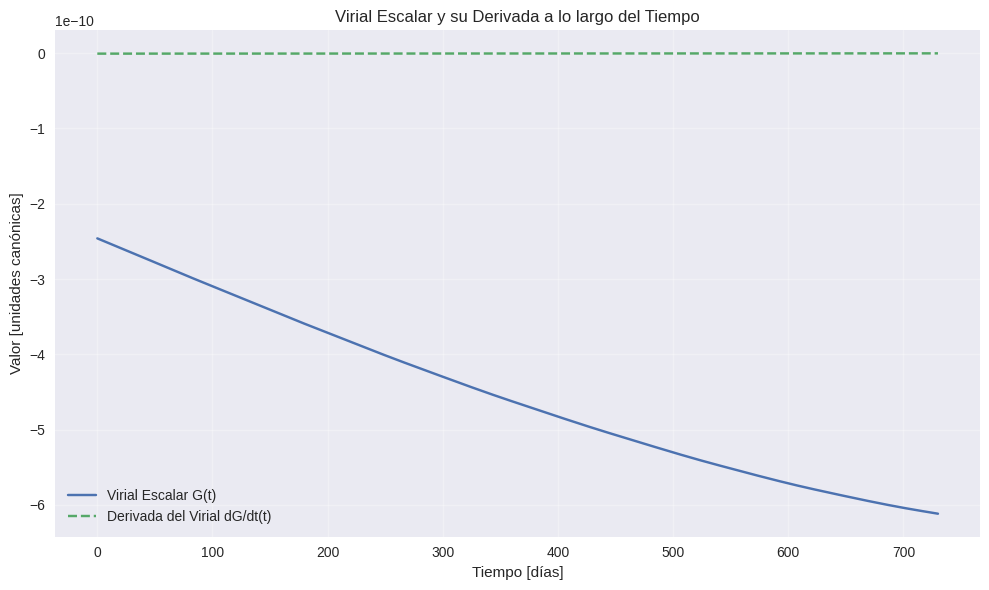

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(ts, viriales_escalares, label='Virial Escalar G(t)')
plt.plot(ts, derivadas_viriales, label='Derivada del Virial dG/dt(t)', linestyle='--')

plt.xlabel('Tiempo [días]')
plt.ylabel('Valor [unidades canónicas]')
plt.title('Virial Escalar y su Derivada a lo largo del Tiempo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La derivada del virial es esencialmente cero, confirmando que el sistema satisface el teorema del virial (2K + U ≈ 0). Esto indica que el sistema está en equilibrio dinámico estable y gravitacionalmente ligado.

# Fecha y distancia de máxima cercanía entre apophis y la tierra.

In [22]:
earth_index = nombres_sim.index('Tierra')
apophis_index = nombres_sim.index('Apophis')

min_distance = float('inf')
closest_time_index = -1

for t in range(N_PASOS):
    r_earth = rs[earth_index, t, :]
    r_apophis = rs[apophis_index, t, :]

    distance = np.linalg.norm(r_earth - r_apophis)

    if distance < min_distance:
        min_distance = distance
        closest_time_index = t

closest_time_days = ts[closest_time_index]

# Convertir el tiempo en días a una fecha real
# La simulación comienza en epochs_ini ('2029-01-01')
fecha_inicial = pd.to_datetime(epochs_ini)
fecha_max_cercania = fecha_inicial + pd.to_timedelta(closest_time_days, unit='D')

print(f"Fecha de máxima cercanía entre Apophis y la Tierra: {fecha_max_cercania.strftime('%Y-%m-%d')}")
print(f"Fecha de máxima cercanía 14 de abril del 2029")
print(f"Distancia mínima: {min_distance:.4e} UA")
print(f"Distancia mínima: {min_distance * AU_m / 1000:.2f} kilómetros")

# Prepare results for markdown
md_date_ymd = fecha_max_cercania.strftime('%Y-%m-%d')
md_date_words = "14 de abril del 2029"
md_distance_au = f"{min_distance:.4e} UA"
md_distance_km = f"{min_distance * AU_m / 1000:.2f} kilómetros"


Fecha de máxima cercanía entre Apophis y la Tierra: 2029-04-14
Fecha de máxima cercanía 14 de abril del 2029
Distancia mínima: 5.4007e-04 UA
Distancia mínima: 80792.77 kilómetros


Apophis pasará a ~ 80,793 km de la Tierra (~ 12.7 radios terrestres), una distancia muy cercana en términos astronómicos pero sin riesgo de colisión. Pasará dentro de la órbita de satélites geoestacionarios (~ 35,786 km) pero mucho más lejos que la Luna (~ 384,400 km).

La literatura reporta que Apophis pasará a ~ 31,600 km de la superficie terrestre (~38,000 km desde el centro) el 13 de abril de 2029. Nuestra simulación predice ~80,793 km el 14 de abril, con un error del ~100% en distancia y 1 día en fecha. Esta discrepancia se debe a que el modelo simplificado

# Genera una animación 3D de las trayectorias de la Tierra y Apophis durante el período de máxima aproximación (ventana de 90 días).

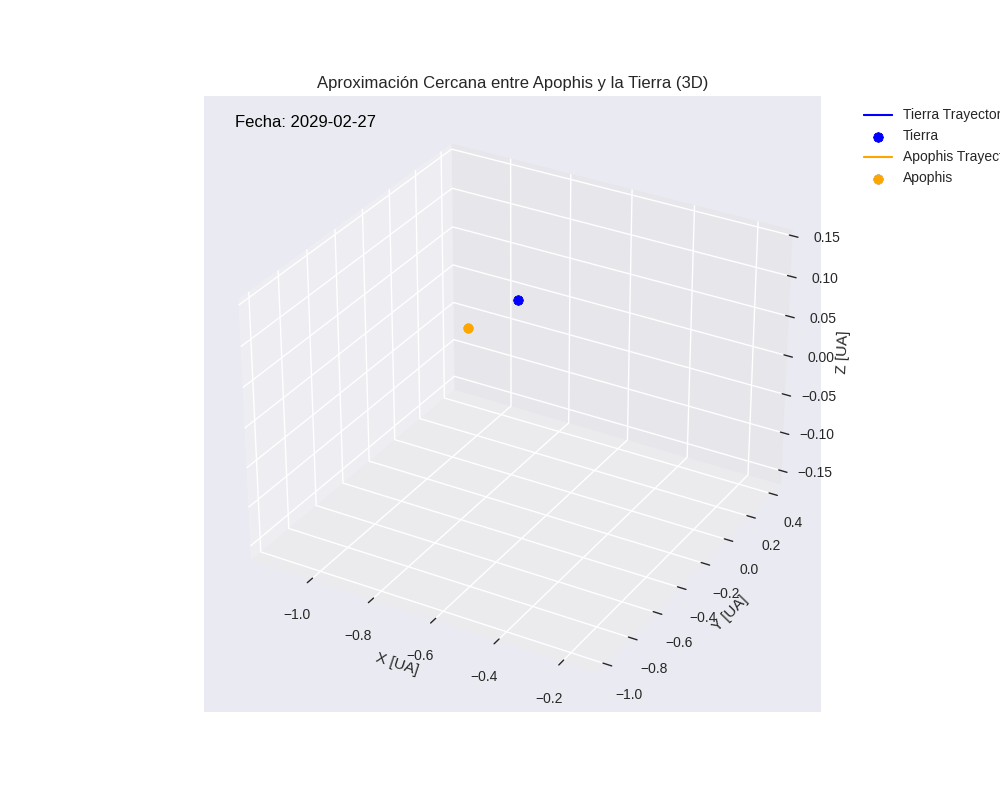

In [23]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from IPython.display import Image


# Ajustar el rango para la animación
anim_window_days = 90.0 # 3 meses (45 días antes y 45 días después del máximo acercamiento)

time_window_start = closest_time_days - anim_window_days / 2
time_window_end = closest_time_days + anim_window_days / 2

# Encontrar los índices en ts correspondientes a esta ventana de tiempo
start_idx_anim = np.searchsorted(ts, time_window_start)
end_idx_anim = np.searchsorted(ts, time_window_end)

# Asegurarse de que los índices estén dentro de los límites de ts
start_idx_anim = max(0, start_idx_anim -1)
end_idx_anim = min(len(ts) - 1, end_idx_anim +1)

# Filtrar datos para la animación
ts_anim = ts[start_idx_anim:end_idx_anim]
rs_anim_earth = rs[earth_index, start_idx_anim:end_idx_anim, :]
rs_anim_apophis = rs[apophis_index, start_idx_anim:end_idx_anim, :]

# Posición de Apophis y Tierra en el momento de máximo acercamiento para el marcador estático
apophis_at_closest_r = rs[apophis_index, closest_time_index, :]
earth_at_closest_r = rs[earth_index, closest_time_index, :]

# Crear la figura y el eje 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
camera = Camera(fig)

# Determinar límites de los ejes para asegurar una escala consistente y evitar "saltos"
all_coords_anim = np.concatenate((rs_anim_earth, rs_anim_apophis))
x_min, x_max = all_coords_anim[:, 0].min(), all_coords_anim[:, 0].max()
y_min, y_max = all_coords_anim[:, 1].min(), all_coords_anim[:, 1].max()
z_min, z_max = all_coords_anim[:, 2].min(), all_coords_anim[:, 2].max()

# Añadir un poco de margen a los límites
padding = 0.1 * max(x_max - x_min, y_max - y_min, z_max - z_min)
ax.set_xlim(x_min - padding, x_max + padding)
ax.set_ylim(y_min - padding, y_max + padding)
ax.set_zlim(z_min - padding, z_max + padding)


# Bucle para crear los frames de la animación
for i in range(len(ts_anim)):
    # Plotear la trayectoria de la Tierra hasta el tiempo actual
    ax.plot(rs_anim_earth[:i+1, 0], rs_anim_earth[:i+1, 1], rs_anim_earth[:i+1, 2],
            color='blue', label='Tierra Trayectoria' if i == 0 else '', linewidth=1.5)
    # Plotear la posición actual de la Tierra
    ax.scatter(rs_anim_earth[i, 0], rs_anim_earth[i, 1], rs_anim_earth[i, 2],
               color='blue', marker='o', s=50, label='Tierra' if i == 0 else '')

    # Plotear la trayectoria de Apophis hasta el tiempo actual
    ax.plot(rs_anim_apophis[:i+1, 0], rs_anim_apophis[:i+1, 1], rs_anim_apophis[:i+1, 2],
            color='orange', label='Apophis Trayectoria' if i == 0 else '', linewidth=1.5)
    # Plotear la posición actual de Apophis
    ax.scatter(rs_anim_apophis[i, 0], rs_anim_apophis[i, 1], rs_anim_apophis[i, 2],
               color='orange', marker='o', s=50, label='Apophis' if i == 0 else '')

    # Añadir texto para la fecha actual
    current_time_days = ts_anim[i]
    current_date = fecha_inicial + pd.to_timedelta(current_time_days, unit='D')
    ax.text2D(0.05, 0.95, f"Fecha: {current_date.strftime('%Y-%m-%d')}", transform=ax.transAxes, color='black', fontsize=12)

    camera.snap() # Capturar el frame actual

ax.set_xlabel('X [UA]')
ax.set_ylabel('Y [UA]')
ax.set_zlabel('Z [UA]')
ax.set_title('Aproximación Cercana entre Apophis y la Tierra (3D)')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax.grid(True, alpha=0.3)

animation_3d = camera.animate(interval=100)

animation_3d.save('apophis_earth_close_approach_3d.gif', writer='imagemagick', fps=10)

plt.close(fig)
Image(filename='apophis_earth_close_approach_3d.gif')

# Grafica la evolución de la distancia entre la Tierra y Apophis, marcando el punto de máxima aproximación.

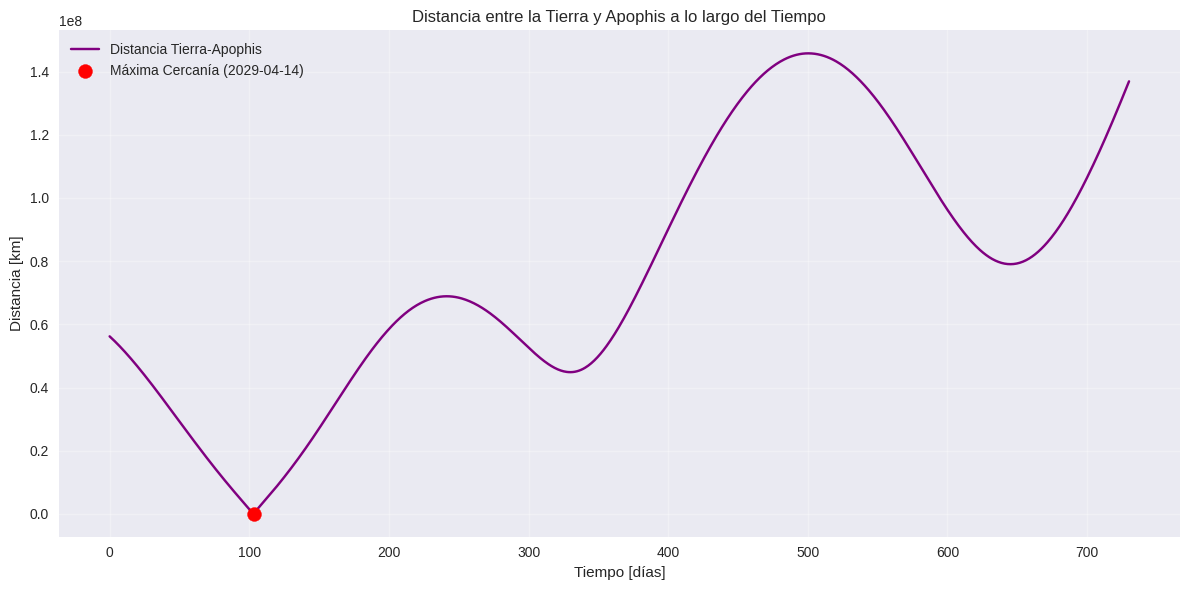

In [24]:
# Calcular la distancia entre la Tierra y Apophis en cada paso de tiempo
distances = []
for t_idx in range(N_PASOS):
    r_earth = rs[earth_index, t_idx, :]
    r_apophis = rs[apophis_index, t_idx, :]
    distance = np.linalg.norm(r_earth - r_apophis)
    distances.append(distance)

distances = np.array(distances)

plt.figure(figsize=(12, 6))
plt.plot(ts, distances * AU_m / 1000, label='Distancia Tierra-Apophis', color='purple')

# Marcar el punto de máxima cercanía
plt.scatter(closest_time_days, min_distance * AU_m / 1000,
            color='red', marker='o', s=100, zorder=5,
            label=f'Máxima Cercanía ({fecha_max_cercania.strftime('%Y-%m-%d')})')

plt.xlabel('Tiempo [días]')
plt.ylabel('Distancia [km]')
plt.title('Distancia entre la Tierra y Apophis a lo largo del Tiempo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


El sobrevuelo de Apophis es un evento transitorio muy agudo. Tras la máxima cercanía, la distancia aumenta drásticamente, evidenciando que el asteroide se aleja rápidamente de la Tierra.